<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/PGCB_BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [6]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/SkillMorph Datasets/PGCB_BD.xlsx')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (92650, 15)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [5]:
import os

# List contents of the directory where the file is expected
!ls '/content/drive/MyDrive/SkillMorph Datasets/'

 cybersecurity_intrusion_data.csv    heart.csv
'dataset_with_all_features v2.csv'   Housing.csv
 diabetes.csv			     PGCB_BD.xlsx
 gym_membership.csv		     StudentsPerformance.csv


In [7]:
import os

drive_path = '/content/drive/MyDrive/SkillMorph Datasets/'
if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"The directory '{drive_path}' does not exist or is not accessible.")

Contents of '/content/drive/MyDrive/SkillMorph Datasets/':
PGCB_BD.xlsx
diabetes.csv
StudentsPerformance.csv
gym_membership.csv
Housing.csv
cybersecurity_intrusion_data.csv
dataset_with_all_features v2.csv
heart.csv


In [11]:
print("Column names in DataFrame df:")
for col in df.columns:
    print(col)

Column names in DataFrame df:
datetime
generation_mw
demand_mw
load_shedding
gas
liquid_fuel
coal
hydro
solar
wind
india_bheramara_hvdc
india_tripura
india_adani
nepal
remarks


In [13]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nTarget Variable Labels (load_shedding Column):\n", df['load_shedding'].value_counts().sort_index())
print("\nNote: The 'load_shedding' column appears to be binary (0 or 1)")

Missing values per column:
 solar          22133
wind           73974
india_adani    85312
nepal          87299
remarks        86257
dtype: int64

Target Variable Labels (load_shedding Column):
 load_shedding
0        77842
1            5
3            2
5            3
6            2
         ...  
13500        1
13800        1
45068        1
60120        1
65359        1
Name: count, Length: 2053, dtype: int64

Note: The 'load_shedding' column appears to be binary (0 or 1)


In [17]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Create a copy of the DataFrame for processing
df_processed = df.copy()

# Separate features (X) and target (y)
# The 'output' column caused a KeyError as it does not exist in the DataFrame.
# Using 'load_shedding' as the target variable, and converting it to binary (0 or 1)
# based on whether load_shedding > 0.
X = df_processed.drop(columns=['load_shedding'])
y = (df_processed['load_shedding'] > 0).astype(int)

# Drop the 'datetime' column as StandardScaler cannot process it
X = X.drop(columns=['datetime'])

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale the features
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20,stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 74120 | Test: 18530


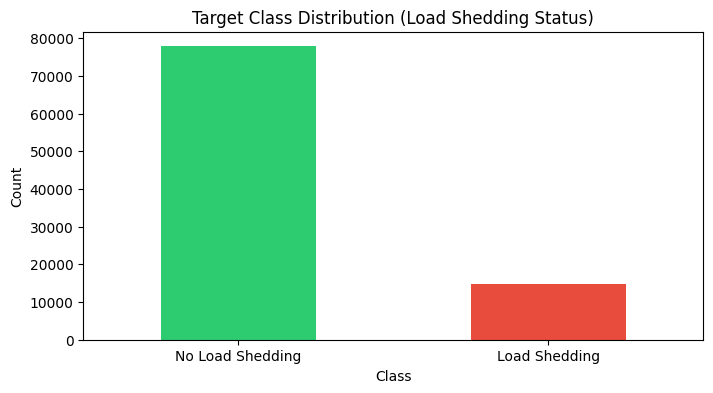

In [20]:
labels = ['No Load Shedding', 'Load Shedding'] # Changed to reflect binary target

# Use the preprocessed binary target 'y' instead of 'df['output']'
counts = y.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e74c3c'] # Adjusted colors for two classes
)

ax.set_xticklabels(labels, rotation=0)
ax.set_title('Target Class Distribution (Load Shedding Status)') # Updated title
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()

In [21]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")

Decision Tree: Acc=0.9640  Precision = 0.9643 Recall = 0.9640 F1=0.9641
KNN (k=5): Acc=0.9575  Precision = 0.9576 Recall = 0.9575 F1=0.9576
Logistic Reg: Acc=0.9246  Precision = 0.9224 Recall = 0.9246 F1=0.9232


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.9278     0.9286  0.9278    0.9282
5            0.9394     0.9421  0.9394    0.9405
10           0.9547     0.9557  0.9547    0.9551
15           0.9621     0.9625  0.9621    0.9622
20           0.9649     0.9651  0.9649    0.9650
None         0.9640     0.9643  0.9640    0.9641


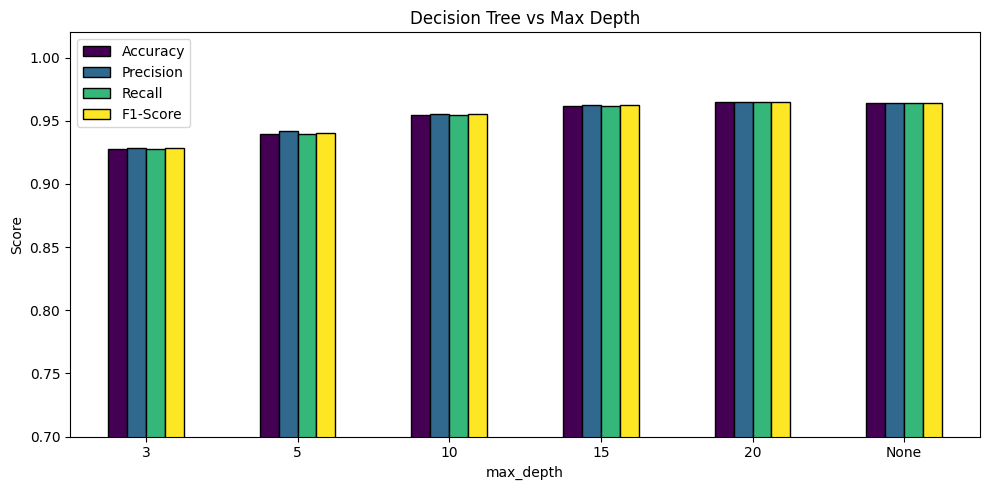

In [22]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [24]:

target_names = ['No Load Shedding', 'Load Shedding'] # Changed to match the 2 classes (0 and 1) in attack_detected
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
                  precision    recall  f1-score   support

No Load Shedding     0.9801    0.9770    0.9785     15568
   Load Shedding     0.8811    0.8957    0.8883      2962

        accuracy                         0.9640     18530
       macro avg     0.9306    0.9363    0.9334     18530
    weighted avg     0.9643    0.9640    0.9641     18530


KNN (k=5)
                  precision    recall  f1-score   support

No Load Shedding     0.9753    0.9741    0.9747     15568
   Load Shedding     0.8648    0.8704    0.8676      2962

        accuracy                         0.9575     18530
       macro avg     0.9201    0.9222    0.9211     18530
    weighted avg     0.9576    0.9575    0.9576     18530


Logistic Reg
                  precision    recall  f1-score   support

No Load Shedding     0.9475    0.9636    0.9555     15568
   Load Shedding     0.7901    0.7194    0.7531      2962

        accuracy                         0.9246     18530
       macro avg     0.8

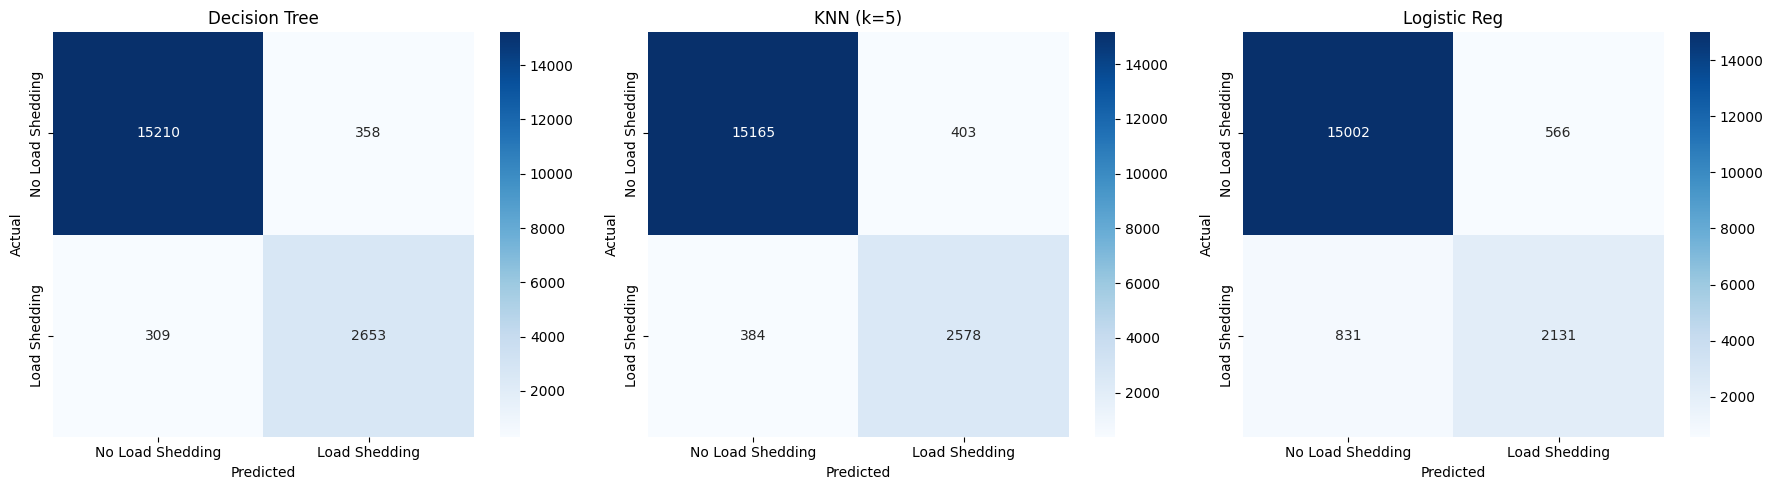

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

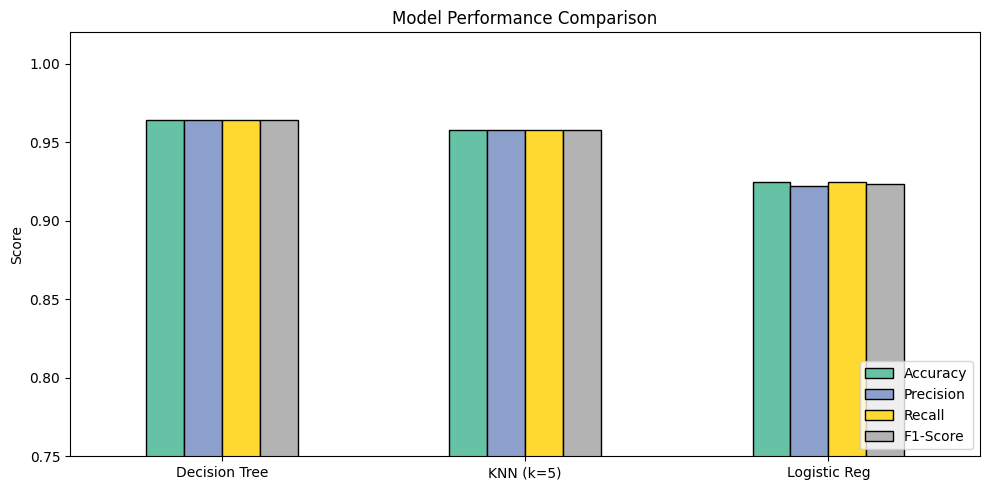


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.9640     0.9643  0.9640    0.9641
KNN (k=5)        0.9575     0.9576  0.9575    0.9576
Logistic Reg     0.9246     0.9224  0.9246    0.9232


In [26]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))

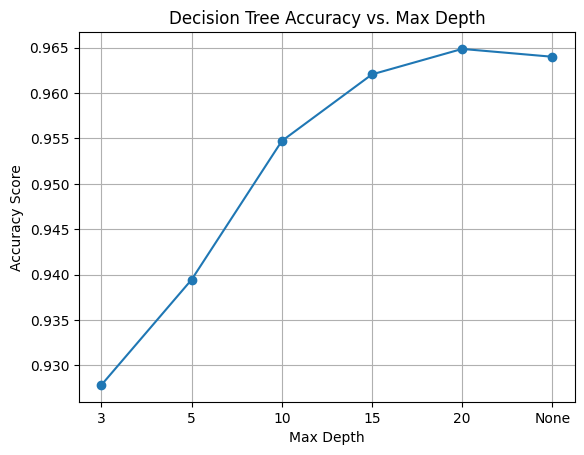

In [29]:
# Line plots are for *ordered* data (time, index, sequence).
# Plotting Decision Tree Accuracy vs. Max Depth from the dt_df results.
scores = dt_df['Accuracy']

fig, ax = plt.subplots()
ax.plot(scores.index.astype(str), scores.values, marker='o') # Use index (max_depth) and values for plotting
ax.set(title='Decision Tree Accuracy vs. Max Depth',
       xlabel='Max Depth', ylabel='Accuracy Score')
plt.grid(True)
plt.show()

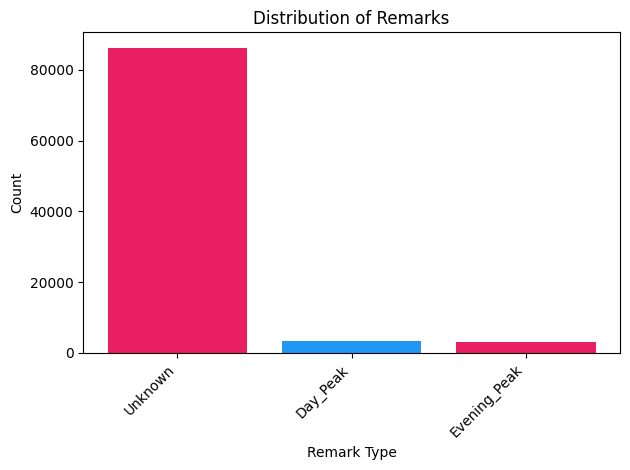

In [31]:
# This cell previously referred to a non-existent 'students' DataFrame.
# We will now plot the distribution of 'remarks' from the existing 'df' DataFrame,
# as it is a categorical-like column. Missing values will be filled with 'Unknown'.
remark_counts = df['remarks'].fillna('Unknown').value_counts()

fig, ax = plt.subplots()
# The provided color list has 2 colors. If 'remarks' has more than 2 unique values,
# Matplotlib will cycle through these colors or use default ones for additional categories.
ax.bar(remark_counts.index, remark_counts.values, color=['#e91e63', '#2196f3'])
ax.set(title='Distribution of Remarks', ylabel='Count')
ax.set_xlabel('Remark Type')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if many categories
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

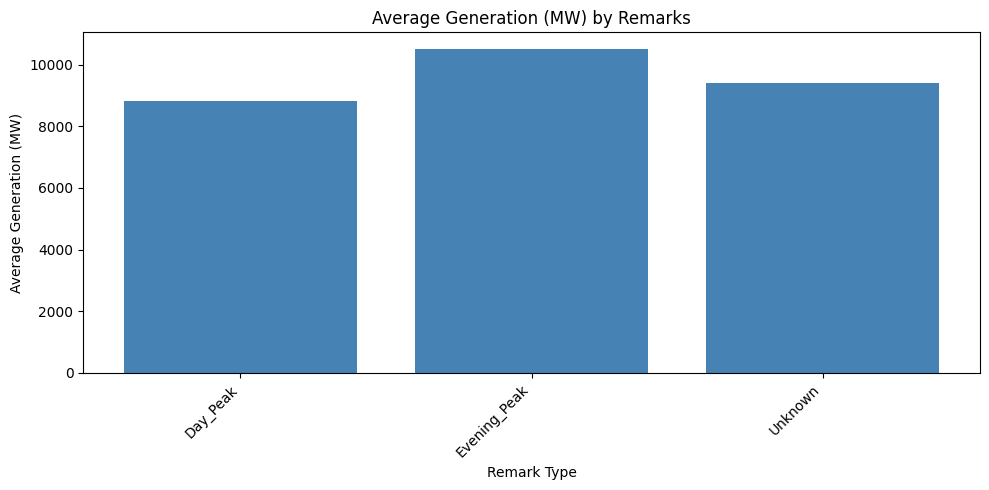

In [33]:
# This cell previously referred to a non-existent 'students' DataFrame.
# We will now plot the average 'generation_mw' grouped by 'remarks' from the existing 'df' DataFrame.
# Missing values in 'remarks' will be filled with 'Unknown'.
avg_generation_by_remarks = df.groupby(df['remarks'].fillna('Unknown'))['generation_mw'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(avg_generation_by_remarks.index, avg_generation_by_remarks.values, color='steelblue')
ax.set(title='Average Generation (MW) by Remarks',
       xlabel='Remark Type', ylabel='Average Generation (MW)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

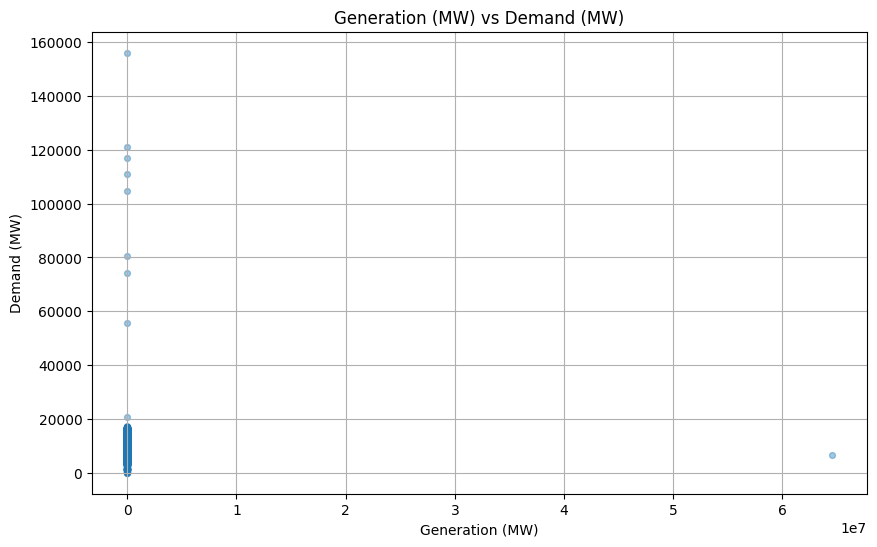

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['generation_mw'], df['demand_mw'],
           alpha=0.4, s=18)
ax.set(title='Generation (MW) vs Demand (MW)',
       xlabel='Generation (MW)', ylabel='Demand (MW)')
plt.grid(True)
plt.show()

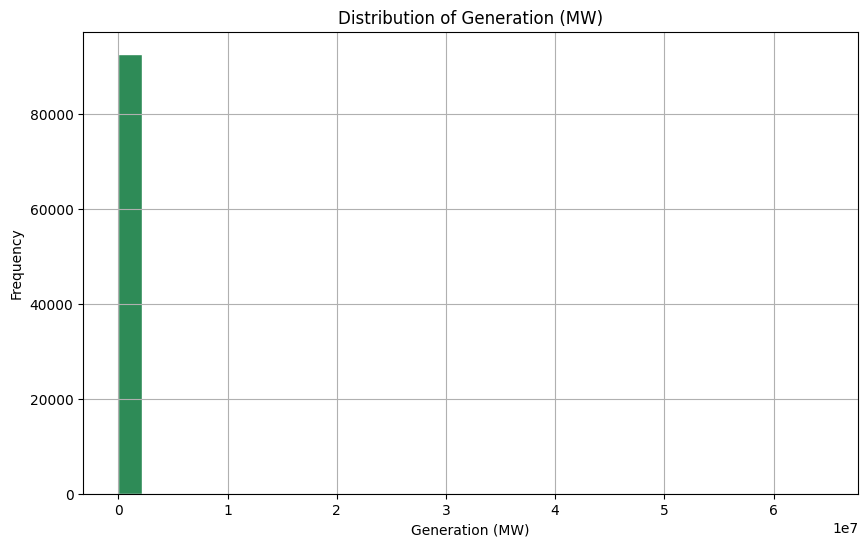

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['generation_mw'], bins=30, color='seagreen', edgecolor='white')
ax.set(title='Distribution of Generation (MW)',
       xlabel='Generation (MW)', ylabel='Frequency')
plt.grid(True)
plt.show()

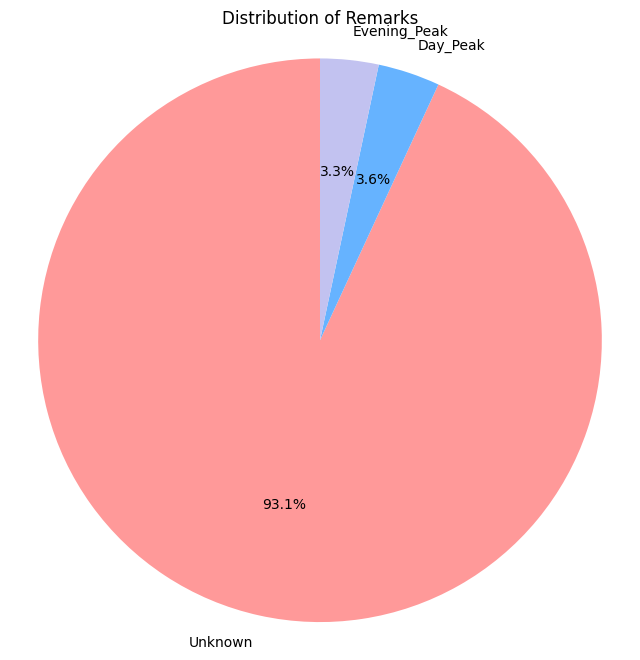

In [41]:
remarks_dist = df['remarks'].fillna('Unknown').value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(remarks_dist.values, labels=remarks_dist.index, autopct='%1.1f%%',
       colors=['#ff9999', '#66b3ff', '#c2c2f0'], startangle=90)
ax.set_title('Distribution of Remarks')
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

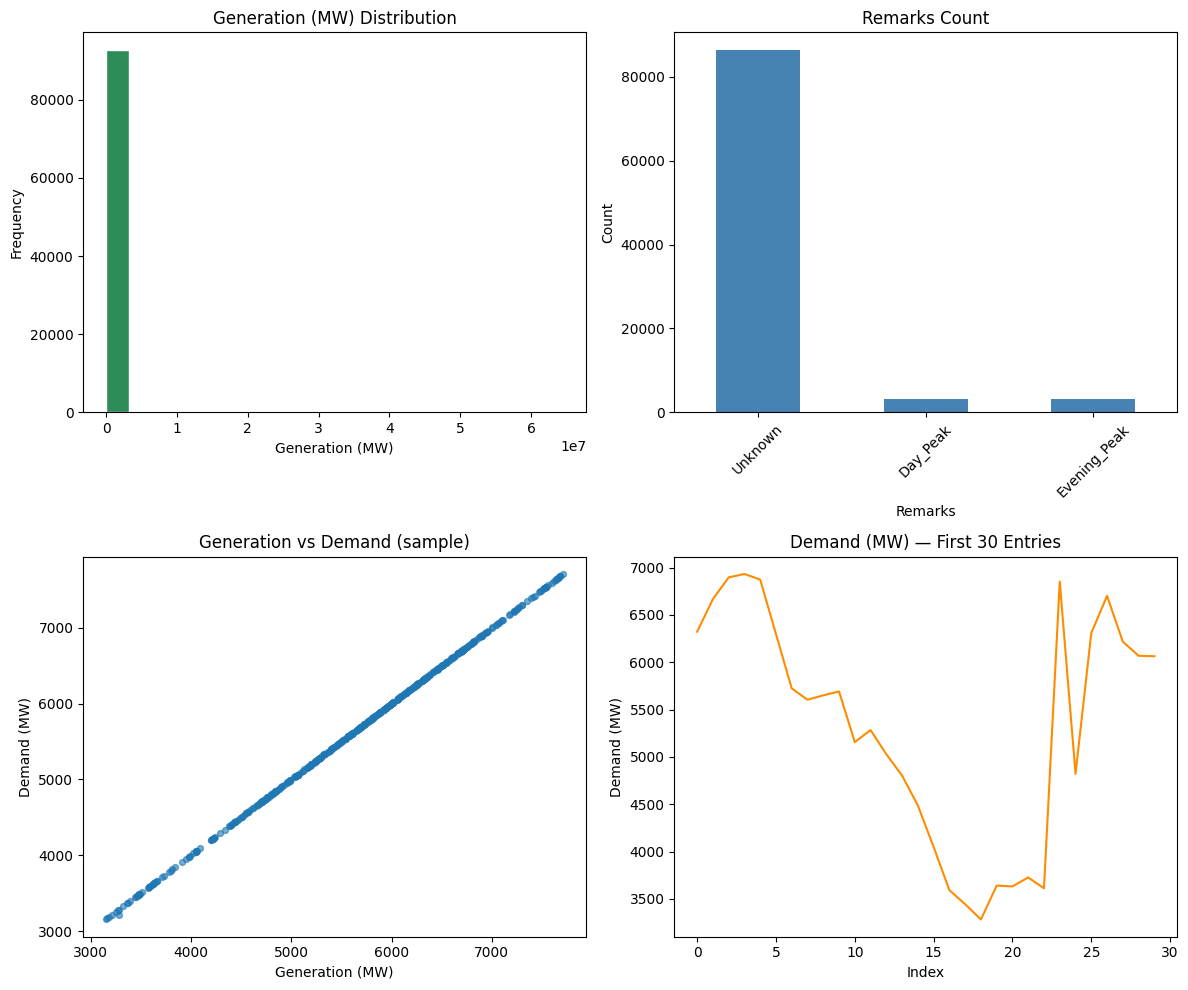

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Histogram of 'generation_mw'
axes[0, 0].hist(df['generation_mw'], bins=20, color='seagreen', edgecolor='white')
axes[0, 0].set_title('Generation (MW) Distribution')
axes[0, 0].set_xlabel('Generation (MW)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Bar chart of 'remarks' count
# Fill NaN values in 'remarks' for plotting
df['remarks'].fillna('Unknown').value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Remarks Count')
axes[0, 1].set_xlabel('Remarks')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45) # Removed 'ha' parameter

# Plot 3: Scatter of 'generation_mw' vs 'demand_mw' (sample)
axes[1, 0].scatter(df['generation_mw'].head(500), # Using a larger sample for better visualization
                   df['demand_mw'].head(500), alpha=0.6, s=18)
axes[1, 0].set(title='Generation vs Demand (sample)',
               xlabel='Generation (MW)', ylabel='Demand (MW)')

# Plot 4: Line plot of 'demand_mw' for first 30 entries
axes[1, 1].plot(df['demand_mw'].head(30), color='darkorange')
axes[1, 1].set_title('Demand (MW) — First 30 Entries')
axes[1, 1].set_xlabel('Index')
axes[1, 1].set_ylabel('Demand (MW)')

plt.tight_layout()
plt.show()